In [1]:
import phdthesisplotstyle as phd
import matplotlib.pyplot as plt
import h5py
import numpy as np
from tol_colors import tol_cset, tol_cmap
tolc = tol_cset("bright")
plt.style.use(phd.PHDTHESISPLOTSTYLE)
import glob
import os
from tqdm import tqdm
import awkward as ak

import h5py
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
import os
import json

In [2]:
with open("../overall_runtime_estimates.json","r") as f:
    data = json.load(f)

In [3]:
data.keys()

dict_keys(['./gen/simple/gamma/w_output', './gen/simple/gamma/physics_list/em/standard_opt2', './gen/simple/gamma/physics_list/em/standard', './gen/simple/gamma/physics_list/em/standard_opt1', './gen/simple/gamma/physics_list/em/Livermore', './gen/simple/gamma/physics_list/em/standard_opt3', './gen/simple/gamma/physics_list/em/Penelope', './gen/simple/gamma/physics_list/em/standard_opt4', './gen/simple/gamma/physics_list/em/LivermorePol', './gen/simple/gamma/physics_list/had/QGSP_BIC', './gen/simple/gamma/physics_list/had/QGSP_BERT', './gen/simple/gamma/physics_list/had/Shielding', './gen/simple/gamma/physics_list/had/FTFP_BERT', './gen/simple/gamma/multithreaded/m5', './gen/simple/gamma/multithreaded/m16', './gen/simple/gamma/multithreaded/m15', './gen/simple/gamma/multithreaded/m17', './gen/simple/gamma/multithreaded/m12', './gen/simple/gamma/multithreaded/m7', './gen/simple/gamma/multithreaded/m1', './gen/simple/gamma/multithreaded/m13', './gen/simple/gamma/multithreaded/m8', './gen

In [4]:
electron_entries = np.sort(np.array([key for key in data.keys() if ("electron" in key and "multithreaded" in key)]))
gamma_entries = np.sort(np.array([key for key in data.keys() if ("gamma" in key and "multithreaded" in key)]))

In [24]:
def plot_speedup(data,entries):
    x = [int(entry.split("/")[-1][1:]) for entry in entries]
    xsort = np.argsort(x)
    x = np.array(x)[xsort]
    y = np.array([data[entry]["event_rate"]["val"] for entry in entries])
    y = y / y[0]
    y = y[xsort]

    m_arr = (y[1:] - y[:-1])/ (x[1:] - x[:-1])
    m = np.mean(m_arr)
    
    fig, ax = plt.subplots(figsize=(phd.figsizes.TextFigure()[0]/15 * len(x),phd.figsizes.TextFigure()[1]))
    ax.plot(x,y,label="Speedup",marker=".",lw=0)
    ax.plot(x,m * (x - 1) + y[0],label="Linear Fit",ls="--",lw=0.5)
    ax.text(0.5,0.9,f"Slope: {m:.2f}",transform=ax.transAxes)
    ax.legend()
    ax.set_ylabel("Speedup")
    #ax.set_xlabel("Number of Threads")
    ax.set_title(".".join(entries[0].split("/")[2:-1]))
    #plt.xticks(rotation=90)
    ax.set_xlabel("Number of Threads")
    ax.set_xticks(x)
    plt.savefig("../figs/speedup_"+"_".join(entries[0].split("/")[2:-1]) + ".png",bbox_inches="tight")

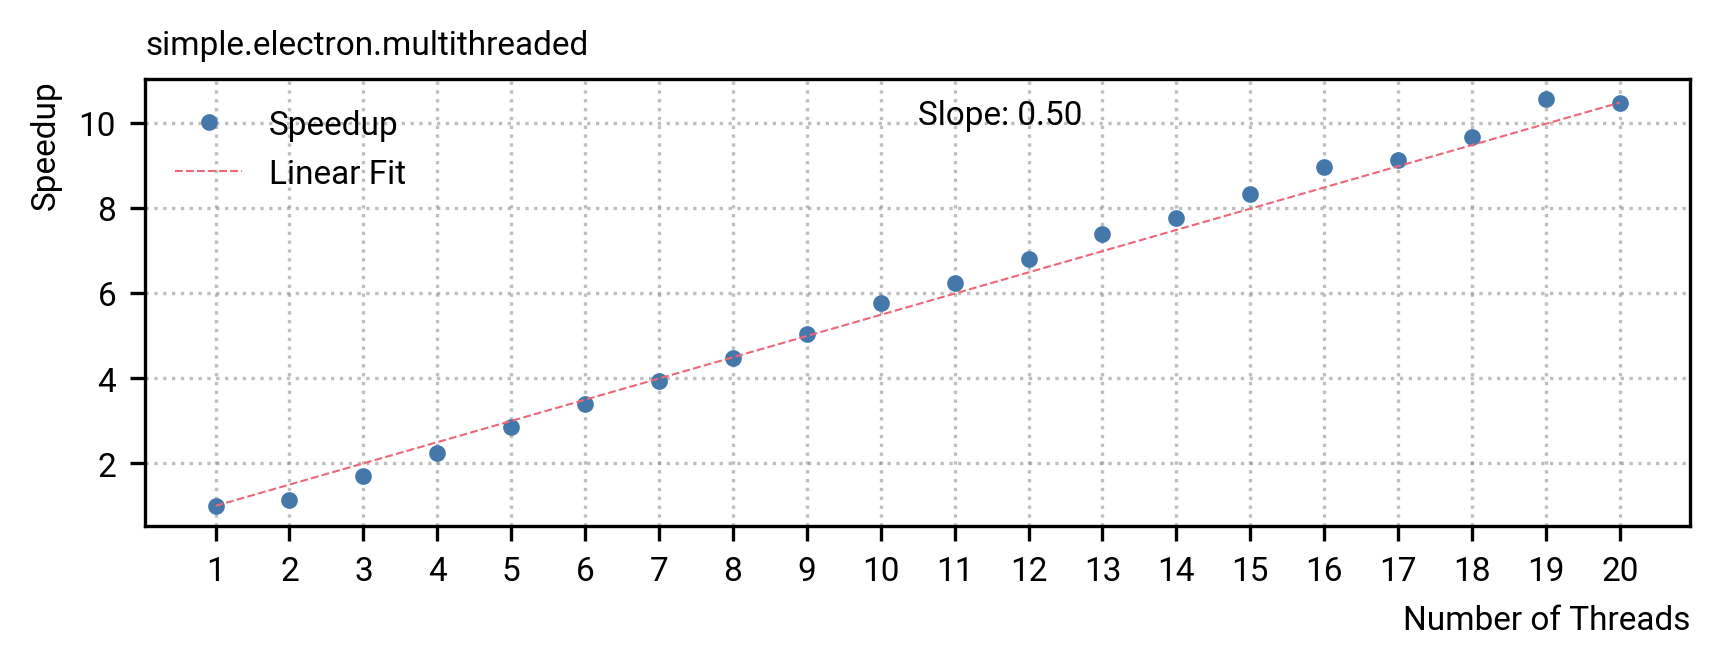

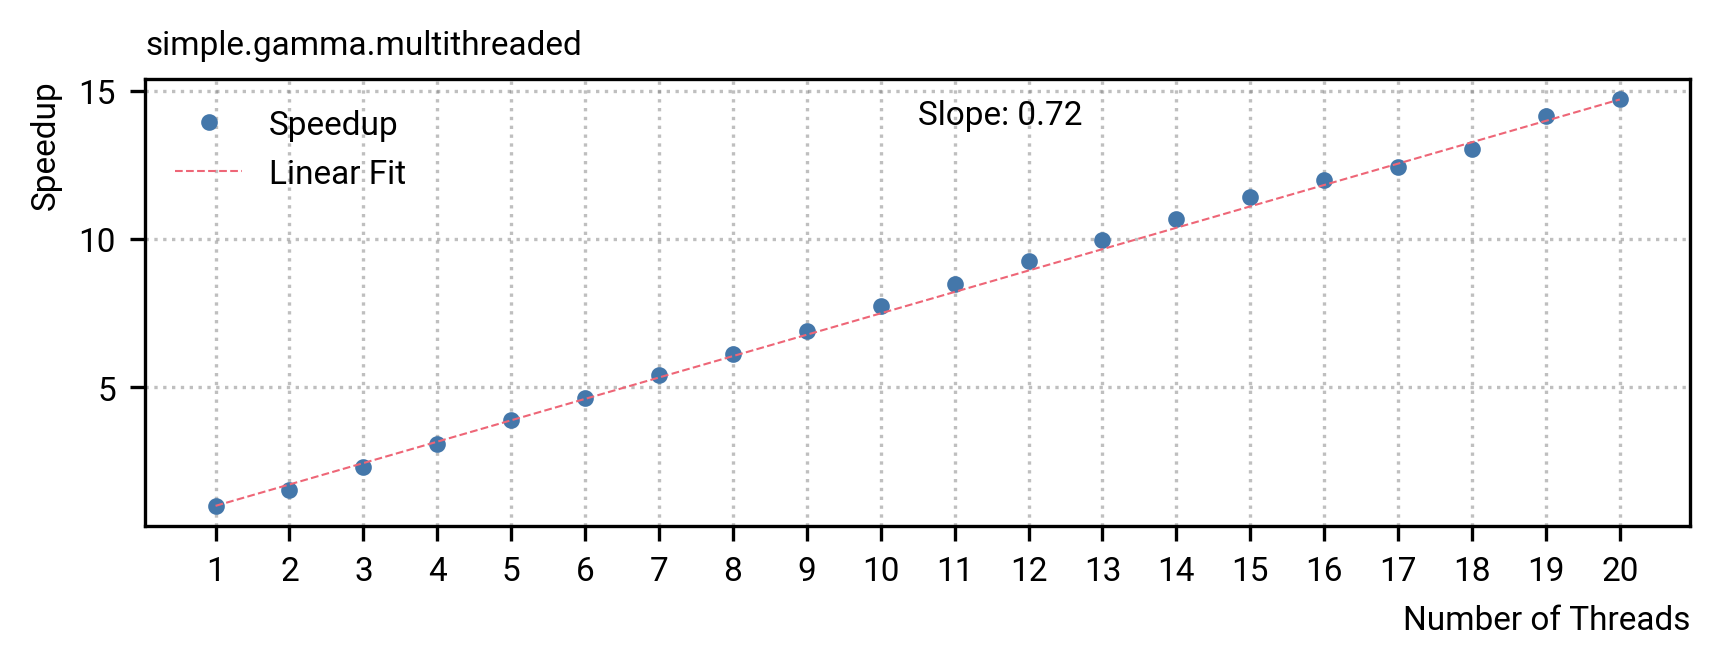

In [25]:
plot_speedup(data,electron_entries)
plot_speedup(data,gamma_entries)